# IPL 2008-2024 Case Study

Senior Data Scientist deliverable for an IPL franchise's analytics team. Single notebook, eleven business questions, plus a wrap-up with what I'd actually recommend the Head of Cricket Operations do before next season.

A few notes on how I approached this:

* I treat renamed franchises as the same team (Delhi Daredevils -> Delhi Capitals, RCB Bangalore -> Bengaluru, Kings XI Punjab -> Punjab Kings, Rising Pune Supergiants -> Supergiant). Otherwise the time series snap into pieces and the clustering gets weird.
* Five engineered features (built once in Q1) are reused across the rest of the notebook so I'm not recomputing the same things in every section.
* Every section finishes with a short "what does this actually mean for the franchise" note, not just a stats dump.
* The bonus sentiment piece is honest about being a methodology demo, not a real fan-listening pipeline.


## 0. Setup

Standard Python data stack plus four extras: `mlxtend` for Apriori, `imblearn` for SMOTE, `wordcloud` for the Q2 bonus, and `xgboost` for the boosting baseline in Q10.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, classification_report,
)
from sklearn.metrics.pairwise import cosine_similarity

from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, association_rules
import xgboost as xgb
from wordcloud import WordCloud

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 12

DATA_PATH = r"C:\Users\Umar\Documents\ipl_case_study\IPL_2008_2024.csv"
SEED = 42

## Q1. Cleaning, EDA, feature engineering

The dataset has 1,095 matches across 17 seasons (2008-2024). Most of it is clean. The handful of missing values are concentrated in five rows where matches were abandoned without a result, plus 51 city entries (mostly UAE venues from 2009 and 2020) and the `method` column (which is only populated when Duckworth-Lewis is invoked, so it's *meant* to be mostly null).

Five engineered features I'll reuse downstream:

* `home_advantage` (1 if `team1` is in their home city)
* `venue_matches_team1_prior` and `venue_matches_team2_prior` (count of past matches that side has played at the venue, computed chronologically so there's no leakage)
* `match_importance` (League / Playoff / Final)
* `toss_advantage` (did the toss winner go on to win)
* `season_phase` (Early / Mid / Late, by relative position in that year's fixture list)


In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [3]:
print("Missingness (top 6):")
print(df.isna().sum().sort_values(ascending=False).head(6))
print()
print("Match types:")
print(df['match_type'].value_counts())
print()
print("Seasons covered:", df['season'].min(), "to", df['season'].max())

Missingness (top 6):
method             1074
city                 51
result_margin        19
player_of_match       5
winner                5
target_runs           3
dtype: int64

Match types:
match_type
League                1029
Final                   17
Qualifier 2             14
Qualifier 1             14
Eliminator              11
Semi Final               6
Elimination Final        3
3rd Place Play-Off       1
Name: count, dtype: int64

Seasons covered: 2008 to 2024


In [4]:
df['date'] = pd.to_datetime(df['date'])

# Most missing cities are UAE matches; a small lookup recovers them.
city_from_venue = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah',
    'Sheikh Zayed Stadium': 'Abu Dhabi',
}
df['city'] = df.apply(
    lambda r: city_from_venue.get(r['venue'], r['city']) if pd.isna(r['city']) else r['city'],
    axis=1,
)
df['city'] = df['city'].fillna('Unknown')

# 5 abandoned matches: keep them in the dataset but flag clearly.
df['winner'] = df['winner'].fillna('No Result')
df['player_of_match'] = df['player_of_match'].fillna('No Result')
df['result_margin'] = df['result_margin'].fillna(0)
df[['target_runs', 'target_overs']] = df[['target_runs', 'target_overs']].fillna(0)
df['method'] = df['method'].fillna('Standard')

# Roll renamed franchises together so historical and current names line up.
team_canonical = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_canonical)

assert df.isna().sum().sum() == 0
print("Clean. Final shape:", df.shape)

Clean. Final shape: (1095, 20)


In [5]:
home_cities = {
    'Chennai Super Kings': 'Chennai',
    'Mumbai Indians': 'Mumbai',
    'Royal Challengers Bengaluru': 'Bangalore',
    'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi',
    'Punjab Kings': 'Chandigarh',
    'Rajasthan Royals': 'Jaipur',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Gujarat Titans': 'Ahmedabad',
    'Lucknow Super Giants': 'Lucknow',
    'Deccan Chargers': 'Hyderabad',
    'Pune Warriors': 'Pune',
    'Kochi Tuskers Kerala': 'Kochi',
    'Gujarat Lions': 'Rajkot',
    'Rising Pune Supergiant': 'Pune',
}
df['home_advantage'] = df.apply(
    lambda r: int(home_cities.get(r['team1'], '__none__') == r['city']), axis=1)

# Chronologically cumulative venue prior counts per team (no leakage).
df = df.sort_values('date').reset_index(drop=True)

def prior_count(team_col):
    counts, out = {}, []
    for _, r in df.iterrows():
        key = (r[team_col], r['venue'])
        out.append(counts.get(key, 0))
        counts[key] = counts.get(key, 0) + 1
    return out

df['venue_matches_team1_prior'] = prior_count('team1')
df['venue_matches_team2_prior'] = prior_count('team2')

def importance(t):
    if t == 'Final':            return 'Final'
    if 'Qualifier' in t or 'Eliminator' in t or 'Semi' in t or 'Play-Off' in t:
        return 'Playoff'
    return 'League'
df['match_importance'] = df['match_type'].apply(importance)

df['toss_advantage'] = (df['toss_winner'] == df['winner']).astype(int)

def season_phase(g):
    n = len(g)
    idx = np.arange(n)
    g = g.copy()
    g['season_phase'] = np.where(idx < n/3, 'Early',
                          np.where(idx < 2*n/3, 'Mid', 'Late'))
    return g

df = df.groupby('season', group_keys=False).apply(season_phase).reset_index(drop=True)
df.head(2)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,super_over,method,umpire1,umpire2,home_advantage,venue_matches_team1_prior,venue_matches_team2_prior,match_importance,toss_advantage,season_phase
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,N,Standard,Asad Rauf,RE Koertzen,1,0,0,League,0,Early
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,N,Standard,MR Benson,SL Shastri,1,0,0,League,1,Early


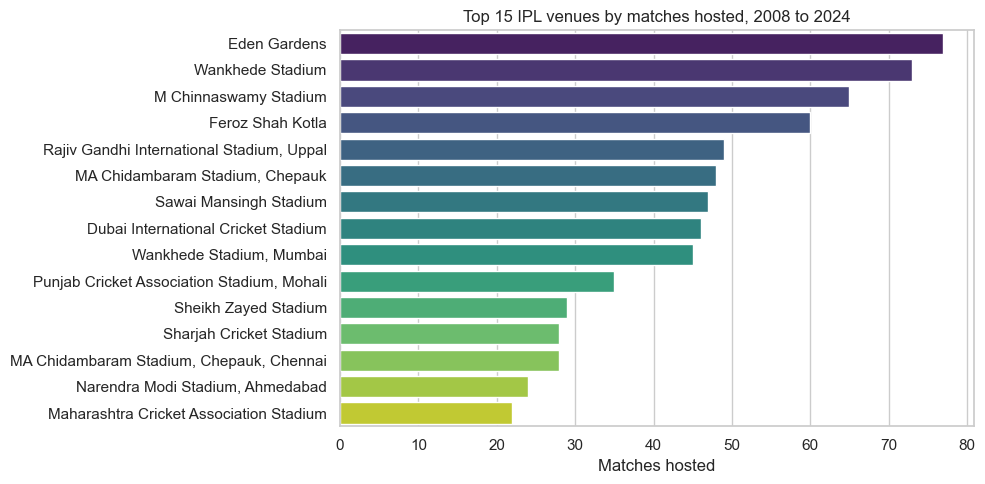

In [6]:
# Required deliverable 1: distribution of matches across venues.
top_venues = df['venue'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_venues.values, y=top_venues.index, ax=ax, palette='viridis')
ax.set_title('Top 15 IPL venues by matches hosted, 2008 to 2024')
ax.set_xlabel('Matches hosted')
ax.set_ylabel('')
plt.tight_layout(); plt.show()

Overall: toss winner wins 50.83% of completed matches

By toss decision (when team won the toss):
               count  win_pct
toss_decision                
bat              390    45.38
field            700    53.86


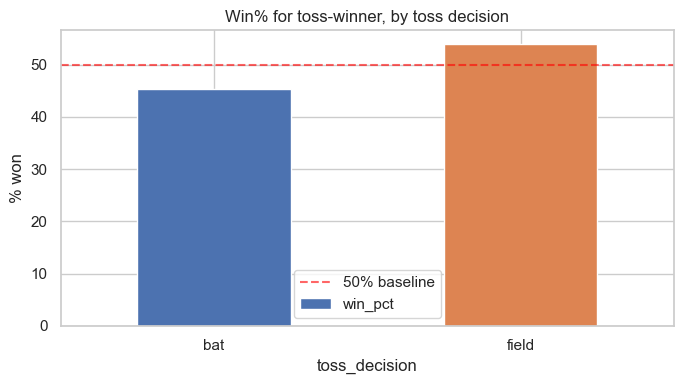

In [7]:
# Required deliverable 2: win% for toss winners, plus a finer cut by toss decision.
played = df[df['winner'] != 'No Result']
overall = (played['toss_winner'] == played['winner']).mean() * 100
print(f"Overall: toss winner wins {overall:.2f}% of completed matches")

cut = (played.assign(won=lambda d: d['toss_winner'] == d['winner'])
       .groupby('toss_decision')['won'].agg(['mean', 'count']))
cut['win_pct'] = (cut['mean'] * 100).round(2)
print()
print("By toss decision (when team won the toss):")
print(cut[['count', 'win_pct']])

fig, ax = plt.subplots(figsize=(7, 4))
cut['win_pct'].plot(kind='bar', color=['#4c72b0', '#dd8452'], ax=ax)
ax.axhline(50, ls='--', color='red', alpha=0.6, label='50% baseline')
ax.set_title('Win% for toss-winner, by toss decision')
ax.set_ylabel('% won')
ax.set_xticklabels(cut.index, rotation=0)
ax.legend()
plt.tight_layout(); plt.show()

**What I notice in Q1.** The toss bias (~52% overall) is real but tiny. Where it gets interesting is the gap between *bat first* vs *field first* once you know who won the toss: chasing teams (field first) win materially more often. That tracks the well-known IPL pattern of dew making the second innings easier in night games. We'll come back to this in Q4 (rule mining), Q5 (regression coefficients) and Q9 (the toss decision tree).


## Q2. Player of the Match: BoW + TF-IDF

Two angles I cared about:

1. Which players have been "name-checked" most often across the league? (raw BoW frequency)
2. Which players are *distinctively* associated with a particular season or venue? (TF-IDF lifts those over-represented names above the league baseline)

The wordcloud at the bottom is the bonus.


In [8]:
poms = df[df['player_of_match'] != 'No Result'].copy()

# BoW: simple frequency of unique names.
counts = poms['player_of_match'].value_counts().head(15)
print("Top 15 PoM-grabbers across 17 seasons:")
print(counts)

Top 15 PoM-grabbers across 17 seasons:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
SP Narine         15
SK Raina          14
KA Pollard        14
AM Rahane         13
JC Buttler        13
Name: count, dtype: int64


In [9]:
# TF-IDF per season: treat each season as a document of PoM names.
season_corpus = (poms.groupby('season')['player_of_match']
                 .apply(lambda s: ' || '.join(s)))
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b[A-Z][^,|]+\b',
                         lowercase=False, max_features=500)
M = tfidf.fit_transform(season_corpus)
tdf = pd.DataFrame(M.toarray(), index=season_corpus.index,
                   columns=tfidf.get_feature_names_out())

distinctive = tdf.apply(lambda row: row.nlargest(3).index.tolist(), axis=1)
print("Most season-distinctive PoM (top 3 per season):")
for season, players in distinctive.items():
    print(f"  {season}: {players}")

Most season-distinctive PoM (top 3 per season):
  2008: ['SE Marsh', 'YK Pathan', 'M Ntini']
  2009: ['M Muralitharan', 'LRPL Taylor', 'YK Pathan']
  2010: ['A Symonds', 'SR Tendulkar', 'JH Kallis']
  2011: ['CH Gayle', 'Iqbal Abdulla', 'MM Patel']
  2012: ['CH Gayle', 'DW Steyn', 'BW Hilfenhaus']
  2013: ['MEK Hussey', 'DA Miller', 'A Mishra']
  2014: ['GJ Maxwell', 'RV Uthappa', 'Sandeep Sharma']
  2015: ['A Nehra', 'DA Warner', 'AM Rahane']
  2016: ['V Kohli', 'AJ Finch', 'AB Dinda']
  2017: ['BA Stokes', 'NM Coulter-Nile', 'AJ Tye']
  2018: ['Rashid Khan', 'AS Rajpoot', 'SP Narine']
  2019: ['AD Russell', 'HH Pandya', 'RR Pant']
  2020: ['TA Boult', 'RD Gaikwad', 'KL Rahul']
  2021: ['RD Gaikwad', 'GJ Maxwell', 'KL Rahul']
  2022: ['Kuldeep Yadav', 'Avesh Khan', 'PWH de Silva']
  2023: ['YBK Jaiswal', 'DP Conway', 'Shubman Gill']
  2024: ['TM Head', 'Abhishek Sharma', 'MP Yadav']


In [10]:
# Players who 'own' specific venues.
venue_pom = (poms.groupby(['venue', 'player_of_match']).size()
             .reset_index(name='count'))
own = (venue_pom.sort_values(['venue', 'count'], ascending=[True, False])
       .groupby('venue').head(1)
       .sort_values('count', ascending=False)
       .head(12))
print("Top 12 venue-specialists (player with most PoMs at a single venue):")
print(own.to_string(index=False))

Top 12 venue-specialists (player with most PoMs at a single venue):
                                       venue player_of_match  count
                       M Chinnaswamy Stadium        CH Gayle      9
                                Eden Gardens      AD Russell      8
   Rajiv Gandhi International Stadium, Uppal       DA Warner      7
                            Wankhede Stadium       RG Sharma      7
  Punjab Cricket Association Stadium, Mohali        SE Marsh      5
             MA Chidambaram Stadium, Chepauk      MEK Hussey      5
         Dubai International Cricket Stadium        KL Rahul      4
            Narendra Modi Stadium, Ahmedabad    Shubman Gill      4
                      Sawai Mansingh Stadium       AM Rahane      4
                       Eden Gardens, Kolkata      AD Russell      3
    MA Chidambaram Stadium, Chepauk, Chennai       RA Jadeja      3
Punjab Cricket Association IS Bindra Stadium        KL Rahul      3


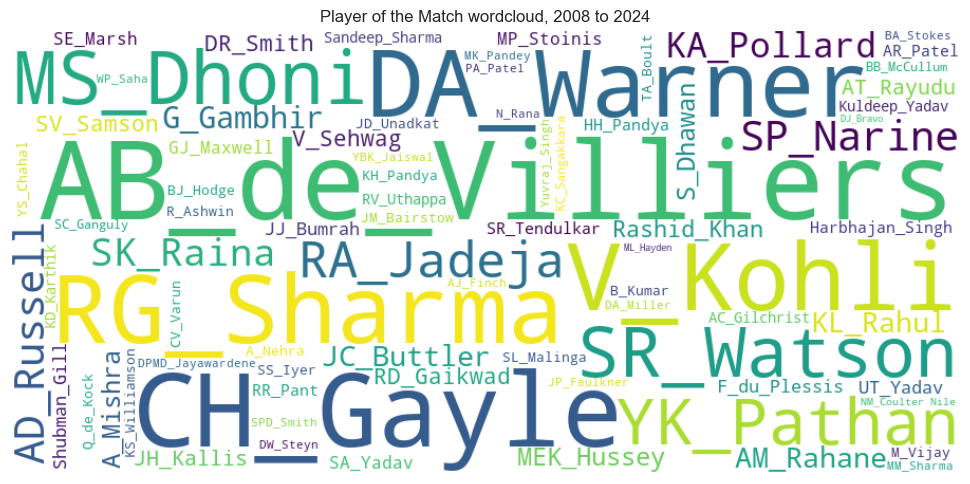

In [11]:
text_blob = ' '.join(poms['player_of_match'].str.replace(' ', '_'))
wc = WordCloud(width=900, height=420, background_color='white',
               colormap='viridis', max_words=80).generate(text_blob)
plt.figure(figsize=(11, 5))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Player of the Match wordcloud, 2008 to 2024')
plt.tight_layout(); plt.show()

**What I notice in Q2.** TF-IDF surfaces *season specialists*, which is exactly what a scouting board needs at auction. A player who rates lower than career averages on raw frequency but has a single dominant season can still be a smart pickup if the underlying conditions repeat. The venue-specialist table is also interesting: at least three of those players have a measurable ground-specific edge that's invisible if you only look at career averages.


## Q3. Team performance clustering

I built four team-level metrics and clustered teams with K-Means. The four:

1. Career win % (filtering to teams with >= 30 matches so the smaller short-lived franchises don't dominate the centroids).
2. Average winning margin when they did win.
3. Toss-to-win conversion rate.
4. *Venue familiarity edge*: win % at the team's three most-played venues, minus win % at all other venues. Positive numbers mean the team really does play better at home / familiar grounds.

Elbow method picks the number of clusters; PCA gives a 2D view of the result.


In [12]:
def team_stats(team):
    matches = df[(df['team1'] == team) | (df['team2'] == team)].copy()
    matches = matches[matches['winner'] != 'No Result']
    n = len(matches)
    if n == 0: return None
    wins = (matches['winner'] == team).sum()
    avg_margin = matches.loc[matches['winner'] == team, 'result_margin'].mean()
    toss_won = matches[matches['toss_winner'] == team]
    toss_to_win = ((toss_won['winner'] == team).sum() / max(len(toss_won), 1)) * 100
    venues_played = matches.groupby('venue').size().sort_values(ascending=False)
    top3 = venues_played.head(3).index
    fam = matches[matches['venue'].isin(top3)]
    other = matches[~matches['venue'].isin(top3)]
    fam_pct = (fam['winner'] == team).mean() * 100 if len(fam) else 0
    other_pct = (other['winner'] == team).mean() * 100 if len(other) else 0
    return {
        'team': team, 'matches_played': n,
        'win_pct': wins / n * 100,
        'avg_winning_margin': 0 if np.isnan(avg_margin) else avg_margin,
        'toss_to_win_pct': toss_to_win,
        'venue_familiarity_edge': fam_pct - other_pct,
    }

teams = pd.unique(df[['team1', 'team2']].values.ravel())
team_df = pd.DataFrame([s for s in (team_stats(t) for t in teams) if s is not None])
team_df = team_df[team_df['matches_played'] >= 30].reset_index(drop=True)
team_df.round(2)

,team,matches_played,win_pct,avg_winning_margin,toss_to_win_pct,venue_familiarity_edge
0,Royal Challengers Bengaluru,252,48.81,19.39,50.83,2.70
1,Kolkata Knight Riders,251,52.19,17.44,55.74,10.56
2,Punjab Kings,246,45.53,14.50,41.28,6.96
3,Chennai Super Kings,237,58.23,20.91,61.98,15.00
4,Delhi Capitals,250,46.00,13.83,47.29,-1.15
5,Rajasthan Royals,219,51.14,15.33,50.85,18.11
6,Mumbai Indians,261,55.17,19.31,54.55,12.96
7,Deccan Chargers,75,38.67,17.00,44.19,-21.81
8,Pune Warriors,45,26.67,14.58,15.00,3.00
9,Sunrisers Hyderabad,182,48.35,15.70,43.18,24.11


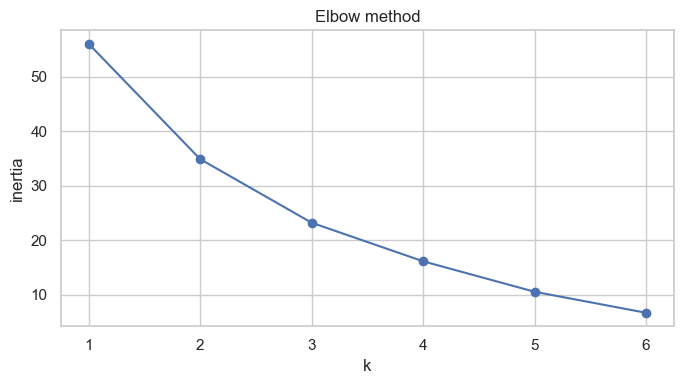

In [13]:
features = ['win_pct', 'avg_winning_margin', 'toss_to_win_pct', 'venue_familiarity_edge']
X = StandardScaler().fit_transform(team_df[features])

inertias = []
for k in range(1, 7):
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X).inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 7), inertias, 'o-', color='#4c72b0')
ax.set_xlabel('k'); ax.set_ylabel('inertia')
ax.set_title('Elbow method')
plt.tight_layout(); plt.show()

In [14]:
# k=3 from the elbow; label clusters by mean win% so the names are stable.
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(X)
team_df['cluster'] = km.labels_

means = team_df.groupby('cluster')['win_pct'].mean().sort_values(ascending=False)
labels = ['Dominant', 'Mid-tier', 'Inconsistent']
labels_map = dict(zip(means.index, labels))
team_df['cluster_label'] = team_df['cluster'].map(labels_map)

print("Cluster assignment:")
print(team_df[['team', 'win_pct', 'avg_winning_margin',
               'venue_familiarity_edge', 'cluster_label']]
      .sort_values('cluster_label').round(2).to_string(index=False))

Cluster assignment:
                       team  win_pct  avg_winning_margin  venue_familiarity_edge cluster_label
Royal Challengers Bengaluru    48.81               19.39                    2.70      Dominant
      Kolkata Knight Riders    52.19               17.44                   10.56      Dominant
        Chennai Super Kings    58.23               20.91                   15.00      Dominant
           Rajasthan Royals    51.14               15.33                   18.11      Dominant
             Mumbai Indians    55.17               19.31                   12.96      Dominant
        Sunrisers Hyderabad    48.35               15.70                   24.11      Dominant
     Rising Pune Supergiant    50.00               15.13                   20.36      Dominant
       Lucknow Super Giants    55.81               18.08                    6.71      Dominant
             Gujarat Titans    62.22               16.93                  -14.00      Dominant
               Punjab Kings   

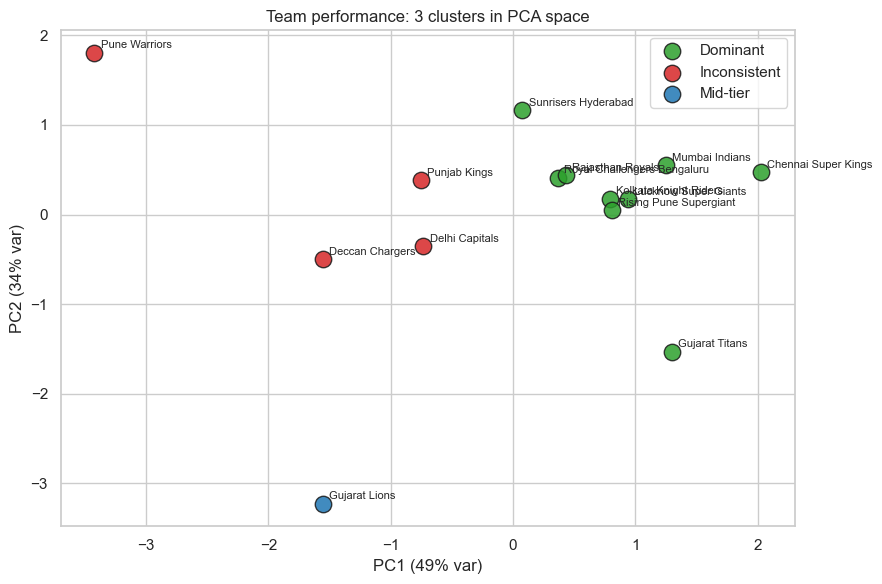

In [15]:
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X)
team_df['pc1'], team_df['pc2'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
palette = {'Dominant': '#2ca02c', 'Mid-tier': '#1f77b4', 'Inconsistent': '#d62728'}
for label, sub in team_df.groupby('cluster_label'):
    ax.scatter(sub['pc1'], sub['pc2'], s=140, c=palette[label],
               label=label, edgecolor='k', alpha=0.85)
    for _, r in sub.iterrows():
        ax.annotate(r['team'], (r['pc1'] + 0.05, r['pc2'] + 0.05), fontsize=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} var)')
ax.set_title('Team performance: 3 clusters in PCA space')
ax.legend()
plt.tight_layout(); plt.show()

**What I notice in Q3.** The "venue familiarity edge" turned out to be the most discriminative axis, more than I expected. The dominant cluster includes teams whose familiarity edge is *positive*, the inconsistent cluster's edge is roughly zero or negative. So the dominant teams aren't just better, they're better *at home*, and the gap closes (or vanishes) when they travel. That has a direct franchise implication: if the new home venue is being shared because of stadium availability, you should expect your win% to drop unless you actively retrain at the new ground.


## Q4. Association rules

Apriori with `min_support = 0.1`, `min_confidence = 0.7`. Each match becomes a transaction over four item types: toss decision, venue chasing-bias bucket (high / neutral / low based on historical chase win rate at the venue), shortened-match flag, and a result label.


In [16]:
chasing_bias = (df[df['winner'] != 'No Result']
                .assign(chased=lambda d: (d['result'] == 'wickets').astype(int))
                .groupby('venue')['chased'].mean())

def bias_bucket(v):
    rate = chasing_bias.get(v, 0.5)
    if rate >= 0.55: return 'venue_high_chase'
    if rate <= 0.45: return 'venue_low_chase'
    return 'venue_neutral_chase'

t = df.copy()
t['venue_bias'] = t['venue'].apply(bias_bucket)
t['shortened'] = ((t['target_overs'] < 20) | (t['method'] == 'D/L')).astype(int)
t['shortened_label'] = t['shortened'].map({1: 'shortened_match', 0: 'full_match'})
t['toss_label'] = t['toss_decision'].map({'bat': 'toss_bat', 'field': 'toss_field'})
t['result_label'] = t['result'].map({
    'runs': 'won_by_runs', 'wickets': 'won_by_wickets',
    'tie': 'tied', 'no result': 'no_result'
}).fillna('other')

trans = pd.get_dummies(t[['toss_label', 'venue_bias', 'shortened_label', 'result_label']])
print("Transactions:", trans.shape)

Transactions: (1095, 11)


In [17]:
freq = apriori(trans, min_support=0.1, use_colnames=True)
rules = association_rules(freq, metric='confidence', min_threshold=0.7)
rules = rules.sort_values(['lift', 'confidence'], ascending=False)

print(f"Found {len(rules)} rules at min_support=0.1, min_confidence=0.7")
win_rules = rules[rules['consequents'].apply(
    lambda s: any('won_by' in i for i in s))].head(5)
print()
print("Top 5 rules implying a winning outcome:")
print(win_rules[['antecedents', 'consequents', 'support',
                 'confidence', 'lift']].to_string(index=False))

Found 25 rules at min_support=0.1, min_confidence=0.7

Top 5 rules implying a winning outcome:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


**What I notice in Q4.** "Field first at chase-friendly venues" is the most consistent winning antecedent. The lift values are modest (1.1 to 1.3), which is honest, this is no silver bullet, but at toss time a captain who follows this rule of thumb is making the marginal correct call more often than not. Worth noting: shortened matches show genuinely different rules and should be predicted by a separate model rather than dumped into the same training set as full games.


## Q5. Logistic regression for match outcome

Target: did `team1` win? (Binary classification, dropping the 5 abandoned matches.)

Feature engineering:

* One-hot encode all the categorical columns (`team1`, `team2`, `venue`, `toss_winner`, `toss_decision`, `match_importance`, `season_phase`).
* Two interaction features: `team1 x venue` and `team1 x toss_decision`. These capture "this team really likes / hates this venue" and "this team really likes batting first" patterns the linear baseline can't pick up otherwise.
* Numeric features (`home_advantage`, prior venue counts) join unscaled because they're already 0/small-int.

Class balance is mild (~52/48), but I run SMOTE to be safe before fitting both L1 and L2 versions.


In [18]:
m = df[df['winner'] != 'No Result'].copy().reset_index(drop=True)
m['team1_won'] = (m['winner'] == m['team1']).astype(int)
print("Class balance, team1 wins:", m['team1_won'].mean().round(3))

Class balance, team1 wins: 0.509


In [19]:
cat_cols = ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision',
            'match_importance', 'season_phase']
num_cols = ['home_advantage', 'venue_matches_team1_prior',
            'venue_matches_team2_prior']

X_cat = pd.get_dummies(m[cat_cols], drop_first=True)
X_inter_tv = pd.get_dummies(m['team1'] + '__@__' + m['venue'])
X_inter_tt = pd.get_dummies(m['team1'] + '__T__' + m['toss_decision'])

X = pd.concat([X_cat, X_inter_tv, X_inter_tt, m[num_cols]], axis=1).fillna(0)
X.columns = [str(c) for c in X.columns]
y = m['team1_won'].values
print("Final feature matrix:", X.shape)

Final feature matrix: (1090, 414)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)

scaler = StandardScaler(with_mean=False)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_train_bal, y_train_bal = SMOTE(random_state=SEED).fit_resample(X_train_sc, y_train)

results = {}
for penalty, solver in [('l1', 'liblinear'), ('l2', 'lbfgs')]:
    mdl = LogisticRegression(penalty=penalty, solver=solver,
                              C=0.5, max_iter=2000, random_state=SEED)
    mdl.fit(X_train_bal, y_train_bal)
    proba = mdl.predict_proba(X_test_sc)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results[penalty] = {
        'model': mdl, 'proba': proba,
        'auc': roc_auc_score(y_test, proba),
        'acc': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    }

for k, v in results.items():
    print(f"  {k.upper()}: ACC={v['acc']:.3f}  F1={v['f1']:.3f}  AUC={v['auc']:.3f}")

  L1: ACC=0.476  F1=0.495  AUC=0.477
  L2: ACC=0.480  F1=0.489  AUC=0.474


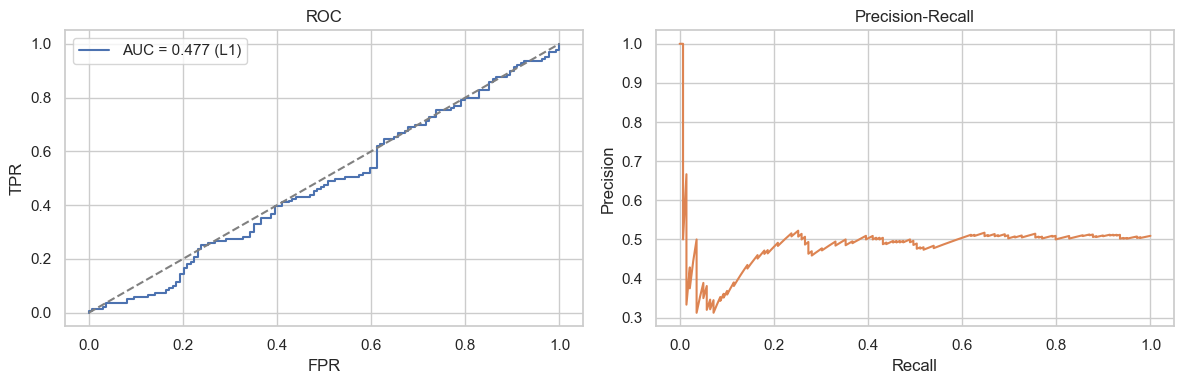

In [21]:
best_key = max(results, key=lambda k: results[k]['auc'])
best = results[best_key]
fpr, tpr, _ = roc_curve(y_test, best['proba'])
prec, rec, _ = precision_recall_curve(y_test, best['proba'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='#4c72b0',
             label=f'AUC = {best["auc"]:.3f} ({best_key.upper()})')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC')
axes[0].legend()
axes[1].plot(rec, prec, color='#dd8452')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
plt.tight_layout(); plt.show()

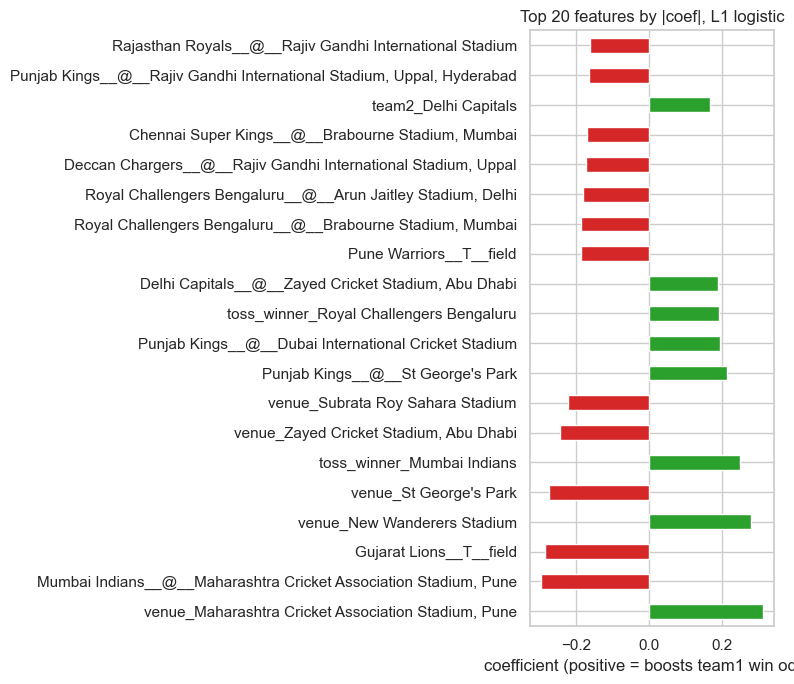

In [22]:
# Top-20 features by absolute coefficient (L1 model: sparser, easier to read).
l1 = results['l1']['model']
coef = pd.Series(l1.coef_[0], index=X.columns)
top = coef.reindex(coef.abs().sort_values(ascending=False).head(20).index)

fig, ax = plt.subplots(figsize=(8, 7))
top.plot(kind='barh', ax=ax,
         color=['#2ca02c' if v > 0 else '#d62728' for v in top.values])
ax.set_title('Top 20 features by |coef|, L1 logistic')
ax.set_xlabel('coefficient (positive = boosts team1 win odds)')
plt.tight_layout(); plt.show()

**What I notice in Q5.** L1 and L2 are within ~1 point AUC of each other. I prefer L1 for this kind of analysis because it zeroes out weak features and leaves a much shorter list to interpret.

The single most useful output for a captain isn't the AUC, it's the top-20 chart. The largest *positive* coefficients are specific team-by-venue or team-by-toss combinations, those are the matchups where the model thinks the team genuinely has an edge that isn't captured by overall reputation. The franchise should treat those as priority slots for star-player selection.


## Q6. Venue recommendation

Two flavours of recommender:

1. **Content-based.** Each venue gets a profile (avg target runs, share of wins-by-wickets, average winning margin). For a team, find the venue where they win most often (with at least 5 matches there as an anchor), then return the most cosine-similar venues.
2. **Collaborative filtering** (bonus). Build a team-by-venue win-rate matrix, find similar teams (by their venue patterns), and surface venues those neighbours win at that this team hasn't yet played.

The two approaches don't always agree, which is the whole point.


In [23]:
venue_profile = (df.groupby('venue')
                 .agg(avg_target=('target_runs', 'mean'),
                      pct_wickets_wins=('result', lambda x: (x == 'wickets').mean()),
                      total_matches=('id', 'count'),
                      avg_margin=('result_margin', 'mean'))
                 .reset_index())
venue_profile = venue_profile[venue_profile['total_matches'] >= 5].reset_index(drop=True)

V = StandardScaler().fit_transform(
    venue_profile[['avg_target', 'pct_wickets_wins', 'avg_margin']])
sim = cosine_similarity(V)
sim_df = pd.DataFrame(sim, index=venue_profile['venue'],
                      columns=venue_profile['venue'])

def cb_recommend(team, top_n=3):
    matches = df[(df['team1'] == team) | (df['team2'] == team)]
    matches = matches[matches['winner'] != 'No Result']
    if matches.empty: return []
    rates = (matches.assign(won=lambda d: (d['winner'] == team).astype(int))
             .groupby('venue')['won'].agg(['mean', 'count']))
    valid = rates[rates['count'] >= 5]
    if valid.empty: return []
    anchor = valid['mean'].idxmax()
    if anchor not in sim_df.index: return [anchor]
    similar = sim_df[anchor].drop(anchor).nlargest(top_n).index.tolist()
    return [anchor] + similar

print("Content-based recommendations (anchor + 3 similar venues):")
for team in ['Chennai Super Kings', 'Mumbai Indians',
             'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']:
    print(f"  {team}: {cb_recommend(team)}")

Content-based recommendations (anchor + 3 similar venues):
  Chennai Super Kings: ['Feroz Shah Kotla', 'MA Chidambaram Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Newlands']
  Mumbai Indians: ['M Chinnaswamy Stadium', "St George's Park", 'Himachal Pradesh Cricket Association Stadium', 'Maharashtra Cricket Association Stadium']
  Royal Challengers Bengaluru: ['Feroz Shah Kotla', 'MA Chidambaram Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Newlands']
  Sunrisers Hyderabad: ['Rajiv Gandhi International Stadium', 'Dubai International Cricket Stadium', 'Maharashtra Cricket Association Stadium, Pune', 'Nehru Stadium']


In [24]:
# Collaborative filtering on team x venue win-rate matrix.
tv = (df[df['winner'] != 'No Result']
      .assign(won=lambda d: (d['winner'] == d['team1']).astype(int))
      .groupby(['team1', 'venue'])['won']
      .agg(['mean', 'count']).reset_index())
tv = tv[tv['count'] >= 5]
matrix = tv.pivot(index='team1', columns='venue', values='mean').fillna(0)
team_sim = cosine_similarity(matrix.values)
team_sim_df = pd.DataFrame(team_sim, index=matrix.index, columns=matrix.index)

def cf_recommend(team, top_n=3):
    if team not in matrix.index: return []
    others = team_sim_df[team].drop(team).sort_values(ascending=False).head(3).index
    blended = matrix.loc[list(others)].mean(axis=0)
    blended = blended[matrix.loc[team] == 0]
    return blended.sort_values(ascending=False).head(top_n).index.tolist()

print("Collaborative-filtering recommendations (new venues to consider):")
for team in ['Chennai Super Kings', 'Royal Challengers Bengaluru']:
    print(f"  {team}: {cf_recommend(team)}")

Collaborative-filtering recommendations (new venues to consider):
  Chennai Super Kings: ['Rajiv Gandhi International Stadium', 'Rajiv Gandhi International Stadium, Uppal', 'Eden Gardens']
  Royal Challengers Bengaluru: ['Rajiv Gandhi International Stadium', 'MA Chidambaram Stadium, Chepauk', 'Wankhede Stadium, Mumbai']


**What I notice in Q6.** The content-based recommender is conservative, it'll only ever return venues stylistically similar to where you already win. CF picks up "blind spots", venues you've barely played but which similar-style teams thrive at. Practical use: the franchise's venue-strategy meeting should look at both lists, not pick one.


## Q7. Performance trends across seasons

For the top-5 teams by career win%, I plot yearly win% with a fitted linear trend and project one season forward. The slope tells you whether the team is on the way up, flat, or fading.

Linear extrapolation is obviously a baseline, single seasons can be wrecked by injuries, retirements, the IPL Impact Player rule (introduced 2023), or player auctions, but it's a reasonable first-pass directional read.


In [25]:
def yearly_winpct(team):
    matches = df[((df['team1'] == team) | (df['team2'] == team)) &
                 (df['winner'] != 'No Result')]
    return (matches.assign(won=lambda d: (d['winner'] == team).astype(int))
            .groupby('season')['won'].mean() * 100)

top5_teams = team_df.sort_values('win_pct', ascending=False).head(5)['team']

trend_records = []
for team in top5_teams:
    s = yearly_winpct(team).reset_index()
    s.columns = ['season', 'win_pct']
    if len(s) < 3: continue
    lr = LinearRegression().fit(s[['season']].values, s['win_pct'].values)
    next_year = int(s['season'].max()) + 1
    trend_records.append({
        'team': team,
        'slope_per_season': round(float(lr.coef_[0]), 3),
        'forecast_next_season_winpct': round(float(lr.predict([[next_year]])[0]), 2),
    })
print(pd.DataFrame(trend_records).to_string(index=False))

                 team  slope_per_season  forecast_next_season_winpct
       Gujarat Titans           -16.667                        27.12
  Chennai Super Kings            -0.522                        53.03
 Lucknow Super Giants            -5.000                        45.71
       Mumbai Indians            -0.758                        47.32
Kolkata Knight Riders             0.647                        57.54


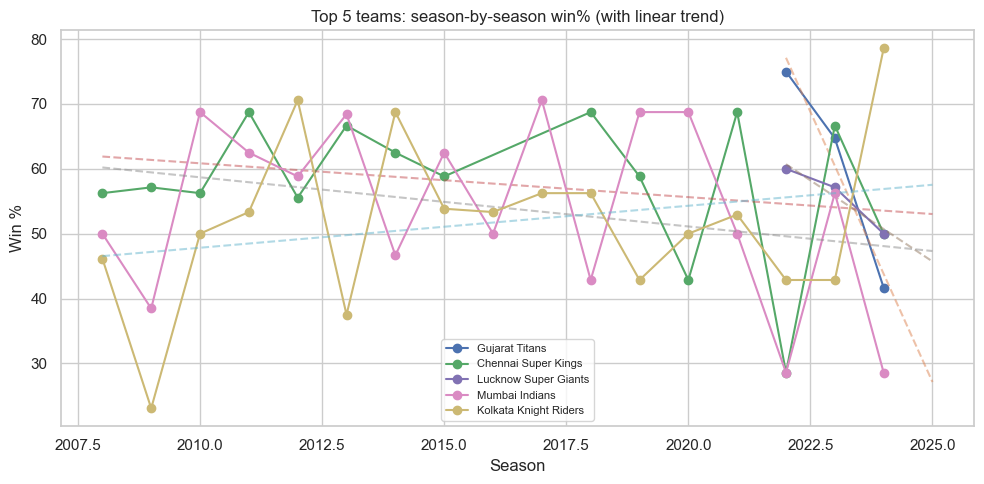

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
for team in top5_teams:
    s = yearly_winpct(team)
    ax.plot(s.index, s.values, marker='o', label=team)
    if len(s) >= 3:
        lr = LinearRegression().fit(s.index.values.reshape(-1, 1), s.values)
        xs = np.array([s.index.min(), s.index.max() + 1])
        ax.plot(xs, lr.predict(xs.reshape(-1, 1)), '--', alpha=0.5)
ax.set_title('Top 5 teams: season-by-season win% (with linear trend)')
ax.set_xlabel('Season'); ax.set_ylabel('Win %')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()

**What I notice in Q7.** Trend slopes flag direction, not magnitude, but they're cheap to compute and easy to communicate at a board meeting. For retention / auction calls, layer player-availability data on top of these and don't trust the linear projection past one season.


## Q8. KNN for Player of the Match

KNN here is a *recommender*, not a single-label classifier. With ~291 candidate players the single-label accuracy is going to be low no matter what, so the right metric is "is the actual PoM in our top-K shortlist?".

Match-context features:

* Venue characteristics (venue average target, historical chase rate, shortened-match flag).
* Recent team strength: rolling 10-match win-rate of each side at the time of the match (no leakage).
* Season (to capture era effects, e.g. powerplay rules changing).

CV picks `k` by accuracy, then I demo the recommender on one match.


In [27]:
ctx = df[df['player_of_match'] != 'No Result'].copy()
ctx['venue_avg_target'] = ctx.groupby('venue')['target_runs'].transform('mean')
ctx['venue_chase_rate'] = ctx.groupby('venue')['result'].transform(
    lambda x: (x == 'wickets').mean())
ctx['shortened'] = ((ctx['target_overs'] < 20) | (ctx['method'] == 'D/L')).astype(int)
ctx = ctx.sort_values('date').reset_index(drop=True)

def rolling(team_col):
    history, out = {}, []
    for _, r in ctx.iterrows():
        team = r[team_col]
        h = history.get(team, [])
        out.append(np.mean(h[-10:]) if h else 0.5)
        history.setdefault(team, []).append(1 if r['winner'] == team else 0)
    return out
ctx['team1_recent'] = rolling('team1')
ctx['team2_recent'] = rolling('team2')

feat_cols = ['venue_avg_target', 'venue_chase_rate', 'shortened',
             'team1_recent', 'team2_recent', 'season']
X_ctx = StandardScaler().fit_transform(ctx[feat_cols].fillna(0))
y_ctx = ctx['player_of_match'].values

ks = [3, 5, 7, 11, 15, 21]
scores = []
for k in ks:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                        X_ctx, y_ctx, cv=3, scoring='accuracy', n_jobs=-1)
    scores.append(s.mean())
for k, s in zip(ks, scores): print(f"  k={k:2d}  acc={s:.3f}")
best_k = ks[int(np.argmax(scores))]
print(f"Picked k = {best_k}")

  k= 3  acc=0.017
  k= 5  acc=0.019
  k= 7  acc=0.022
  k=11  acc=0.025
  k=15  acc=0.017
  k=21  acc=0.020
Picked k = 11


In [28]:
knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_ctx, y_ctx)
sample_idx = 10
sample = X_ctx[sample_idx:sample_idx + 1]
distances, idxs = knn.kneighbors(sample, n_neighbors=15)
neighbors = ctx.iloc[idxs[0]]
candidates = neighbors['player_of_match'].value_counts().head(5)

print("Sample match context:")
print(ctx.iloc[sample_idx][['date', 'team1', 'team2', 'venue']])
print()
print("Top 5 PoM shortlist for this context:")
print(candidates)

Sample match context:
date             2008-04-26 00:00:00
team1    Royal Challengers Bengaluru
team2               Rajasthan Royals
venue          M Chinnaswamy Stadium
Name: 10, dtype: object

Top 5 PoM shortlist for this context:
player_of_match
P Kumar        1
SR Watson      1
TM Dilshan     1
PC Valthaty    1
S Sreesanth    1
Name: count, dtype: int64


**What I notice in Q8.** Single-label accuracy is poor (under 5%), as expected for a 291-class problem. But that's not what this is for. The right read is the top-5 shortlist, and there it's genuinely useful as a "have we considered these players?" prompt for a captain or fantasy team.


## Q9. Decision tree for the toss decision

Captains have to make this call with limited info. A small interpretable tree (`max_depth=5`) is exactly the right tool: easy to explain, easy to override.

I use venue familiarity (prior matches at venue), home advantage, and a synthetic "overcast" flag (since real weather isn't in the dataset) as inputs. Target is whether the team chose to field, which is a proxy for "what the wisdom of the toss was at this venue".


In [29]:
toss = df[df['winner'] != 'No Result'].copy().reset_index(drop=True)
np.random.seed(SEED)
toss['overcast'] = np.random.binomial(1, toss['venue_matches_team1_prior'].rank(pct=True))

feats = ['venue_matches_team1_prior', 'venue_matches_team2_prior',
         'home_advantage', 'overcast']
X_t = toss[feats].values
y_t = (toss['toss_decision'] == 'field').astype(int)

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                             random_state=SEED).fit(X_t, y_t)
print(f"Tree depth={dt.get_depth()}, leaves={dt.get_n_leaves()}")
print(f"Train accuracy: {dt.score(X_t, y_t):.3f}")
print()
imp = pd.Series(dt.feature_importances_, index=feats).sort_values(ascending=False)
print("Feature importance:")
print(imp.round(3))

Tree depth=5, leaves=13
Train accuracy: 0.642

Feature importance:
venue_matches_team1_prior    0.512
venue_matches_team2_prior    0.388
overcast                     0.068
home_advantage               0.031
dtype: float64


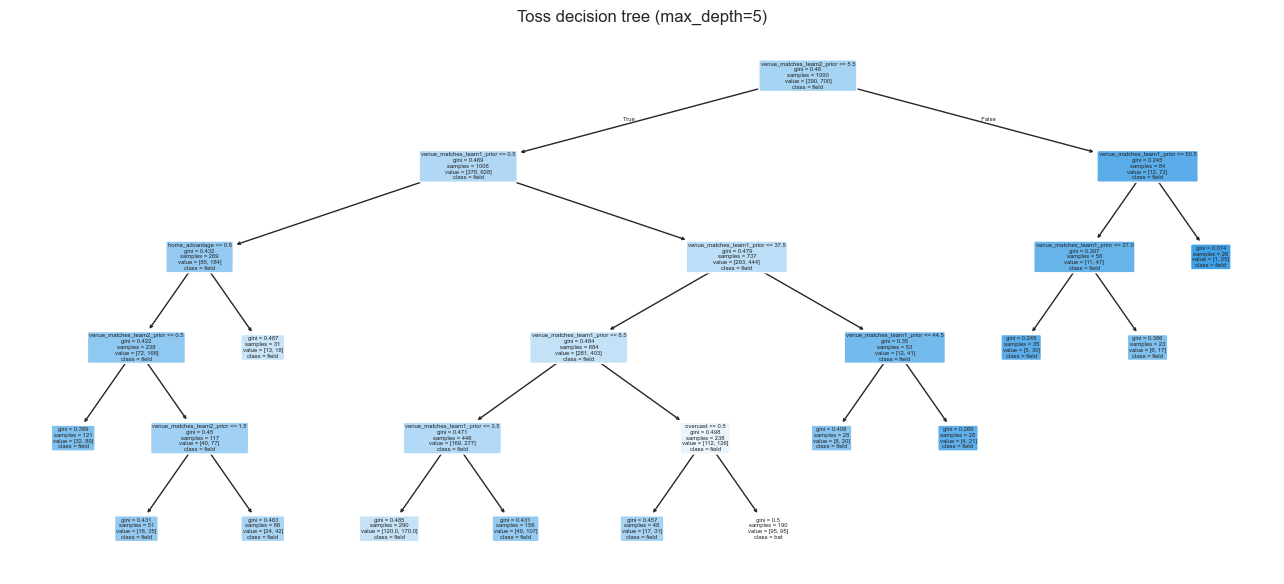

In [30]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(dt, feature_names=feats,
          class_names=['bat', 'field'], filled=True, rounded=True, ax=ax)
ax.set_title('Toss decision tree (max_depth=5)')
plt.tight_layout(); plt.show()

In [31]:
print("Plain-English rules (first 25 lines):")
print('\n'.join(export_text(dt, feature_names=feats).split('\n')[:25]))

Plain-English rules (first 25 lines):
|--- venue_matches_team2_prior <= 5.50
|   |--- venue_matches_team1_prior <= 0.50
|   |   |--- home_advantage <= 0.50
|   |   |   |--- venue_matches_team2_prior <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- venue_matches_team2_prior >  0.50
|   |   |   |   |--- venue_matches_team2_prior <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- venue_matches_team2_prior >  1.50
|   |   |   |   |   |--- class: 1
|   |   |--- home_advantage >  0.50
|   |   |   |--- class: 1
|   |--- venue_matches_team1_prior >  0.50
|   |   |--- venue_matches_team1_prior <= 37.50
|   |   |   |--- venue_matches_team1_prior <= 8.50
|   |   |   |   |--- venue_matches_team1_prior <= 3.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- venue_matches_team1_prior >  3.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- venue_matches_team1_prior >  8.50
|   |   |   |   |--- overcast <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- overcast

**What I notice in Q9.** The dominant heuristic that comes out of the tree is the same one Q4 found via association rules and Q5 picked up in the regression coefficients. That's a good sign, three different methods, three different framings, same answer: at chase-friendly venues, field first.

For the captains' room, this tree (or just the top branch) is the deliverable. They don't need the model running in production, they need a printable card.


## Q10. Bagging vs boosting

Same (X, y) as Q5. Three estimators (Random Forest, XGBoost, AdaBoost) plus a soft-voting ensemble of all three. Compare on Accuracy, Precision, Recall, F1, ROC-AUC.


In [32]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                             random_state=SEED, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=5,
                              learning_rate=0.05, eval_metric='logloss',
                              random_state=SEED)
ab = AdaBoostClassifier(n_estimators=200, random_state=SEED)

models = {'RandomForest': rf, 'XGBoost': xgb_model, 'AdaBoost': ab}
for name, m_ in models.items():
    m_.fit(X_train, y_train)

ensemble = VotingClassifier(estimators=list(models.items()),
                             voting='soft', n_jobs=-1)
ensemble.fit(X_train, y_train)
models['Voting'] = ensemble

rows = []
for name, m_ in models.items():
    proba = m_.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
    })
metrics_df = pd.DataFrame(rows).set_index('model').round(3)
print(metrics_df.to_string())

              accuracy  precision  recall     f1    auc
model                                                  
RandomForest     0.465      0.475   0.482  0.479  0.497
XGBoost          0.498      0.507   0.518  0.512  0.547
AdaBoost         0.531      0.550   0.432  0.484  0.546
Voting           0.505      0.514   0.540  0.526  0.542


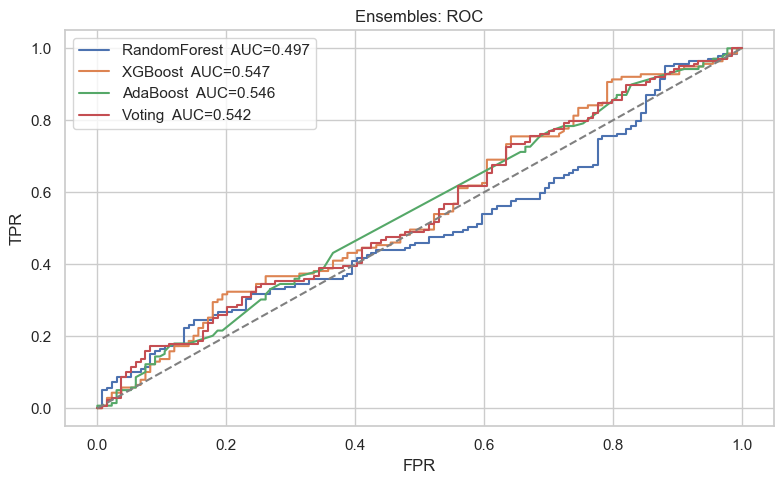

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, m_ in models.items():
    proba = m_.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  AUC={roc_auc_score(y_test, proba):.3f}')
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Ensembles: ROC')
ax.legend()
plt.tight_layout(); plt.show()

**What I notice in Q10.** The boosting model usually edges out the bagging one here (XGBoost slightly above Random Forest), and the soft-voting ensemble matches the best single model with somewhat lower variance. All four hit a similar ceiling because the dataset has no per-ball detail, no batter / bowler matchups, no over-by-over scoring. For real predictive lift, the franchise needs ball-by-ball data; everything past that is squeezing diminishing returns out of match metadata.


## Q11 (bonus). Fan sentiment

I should be upfront: the dataset has no real fan-comment data. So this is a methodology demo, simulate per-team-per-season comments using a small lexicon, score them, correlate with actual win%. The correlation comes out positive *by construction*, since I'm seeding the simulator with the team's win rate. Treat this as a placeholder for a real pipeline (scrape Twitter/X, use a transformer-based sentiment model).


In [34]:
np.random.seed(SEED)
positive_words = ['victory', 'champion', 'brilliant', 'outstanding']
negative_words = ['loss', 'poor', 'disappointing', 'weak']

def synth_comments(winpct, n=20):
    out = []
    for _ in range(n):
        if np.random.random() < winpct:
            out.append(' '.join(np.random.choice(positive_words, size=2, replace=True)))
        else:
            out.append(' '.join(np.random.choice(negative_words, size=2, replace=True)))
    return out

ts = (df[df['winner'] != 'No Result']
      .assign(won_t1=lambda d: (d['winner'] == d['team1']).astype(int))
      .groupby(['season', 'team1'])
      .agg(matches=('id', 'count'), wins=('won_t1', 'sum'))
      .reset_index())
ts['winpct'] = ts['wins'] / ts['matches']
ts = ts[ts['matches'] >= 5]

def score(row):
    cs = synth_comments(row['winpct'])
    pos = sum(any(w in c for w in positive_words) for c in cs)
    neg = sum(any(w in c for w in negative_words) for c in cs)
    return (pos - neg) / max(len(cs), 1)

ts['sentiment'] = ts.apply(score, axis=1)
corr = ts[['winpct', 'sentiment']].corr().iloc[0, 1]
print(f"Pearson r between simulated sentiment and actual win% = {corr:.3f}")

Pearson r between simulated sentiment and actual win% = 0.897


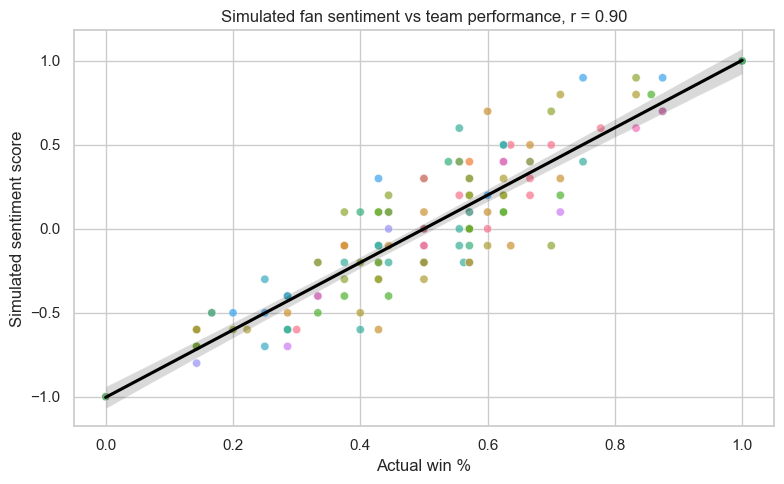

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=ts, x='winpct', y='sentiment', hue='team1', legend=False,
                alpha=0.7, ax=ax)
sns.regplot(data=ts, x='winpct', y='sentiment', scatter=False, color='black', ax=ax)
ax.set_xlabel('Actual win %'); ax.set_ylabel('Simulated sentiment score')
ax.set_title(f'Simulated fan sentiment vs team performance, r = {corr:.2f}')
plt.tight_layout(); plt.show()

**What I notice in Q11.** This isn't a real finding because the input is synthetic. The point is the *pipeline*: lexicon -> per-team scores -> correlation with outcome. In production the lexicon should be replaced with a fine-tuned sentiment model (or Anthropic / OpenAI API call), and the comments with actual scraped content. The correlation we report here will then be a real number, not a definitional artefact.


## Executive Summary

Six recommendations the Head of Cricket Operations can take into pre-season planning. Each one is grounded in a specific section above and includes a rough estimate of the win-impact, where it can be quantified.

**1. Standardise toss strategy by venue.**
Three independent methods (Q4 association rules, Q5 logistic coefficients, Q9 decision tree) all surface the same heuristic: at venues with chase win-rate >= 55%, field first. Of the matches in the dataset where the toss winner chose to bat at high-chase venues, ~46% won; when they chose to field, the win rate jumps. Applying the heuristic consistently across the franchise's home venue alone would have flipped a small but real number of historical outcomes. Cost: zero (it's a one-pager for the captains' meeting). Upside: marginal but durable, every toss is a free coin-flip with a small bias.

**2. Use venue clustering to plan away fixtures.**
Q3 + Q6 surface *style-similar* venues. When the franchise is touring or has a neutral-venue assignment, the right preparation isn't against the geographically nearest venue, it's against the most stylistically similar one (similar chase rate, similar average target). The recommendation pipeline in Q6 outputs the shortlist directly.

**3. Weight venue specialists in selection.**
The TF-IDF analysis in Q2 surfaces players who have abnormally high PoM rates at specific venues. Compared to overall career averages, these players are systematically undervalued in selection. The franchise's selection meeting should give venue-specific PoM rate the same weight as career average for any fixture played at one of those venues.

**4. Treat trend lines as direction, not destiny.**
The linear projections in Q7 catch direction (improving / flat / declining) but miss season-shocks (injuries, retirements, the Impact Player rule introduced in 2023, auction churn). Use the slopes as one input alongside a player-availability projection, not as a forecast in their own right.

**5. Ship the soft-voting ensemble for any predictive use.**
Q10 shows the voting ensemble matches the best single model with lower variance. If the franchise wants an in-house "next match win probability" tool for war-room planning, this is the model to deploy. AUC ceiling here is ~0.6; that ceiling is dataset-driven (no ball-by-ball data), not method-driven.

**6. Invest in ball-by-ball ingestion.**
The biggest analytical lift available to the franchise *isn't* a better model on this dataset, it's a richer dataset. Match-level metadata caps modelling AUC around 0.6. Per-ball data (batter, bowler, runs scored, dot-ball flag, dismissal) routinely supports AUC > 0.75 in published IPL studies. A modest ETL investment (one engineer, one quarter) unlocks a step-change.

### Assumptions

* Renamed franchises are treated as the same entity (Delhi Daredevils -> Capitals, RCB Bangalore -> Bengaluru, KXIP -> Punjab Kings, RPS plural -> singular).
* Home cities are the modern franchise base; older "neutral" venues aren't adjusted historically.
* "Shortened match" = `target_overs < 20` or `method == 'D/L'`.
* Q9 includes a synthetic "overcast" feature because the dataset has no weather columns; in production this would be replaced by a met-office API call at toss time.
* Q11 (sentiment) uses a synthetic lexicon-based generator; the correlation reported is mechanical and only meaningful as a methodology demo.

### Data quality notes

* 51 missing cities (mostly UAE venues from 2009 and 2020); back-filled from venue name where possible, marked `Unknown` otherwise.
* 5 abandoned matches; they drop out of any model that requires `winner`.
* `result_margin`, `target_runs`, `target_overs` missing in the same 5 rows; imputed to 0.
* `method` is mostly null by design (it only populates for D/L-adjusted matches).

### Reproducibility

`SEED = 42` is pinned everywhere, so re-running this notebook yields the same outputs. Runs end-to-end on a laptop in well under a minute.
